<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/Image_Processing_with_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing with OpenCV: Contrast, Blur, Sharpening, and Color Spaces

In [73]:
import cv2 # Import OpenCV for image processing
import numpy as np # Import NumPy for numerical operations
import matplotlib.pyplot as plt # Import Matplotlib for displaying images
from google.colab import files # Import Colab utility for file uploads

In [74]:
uploaded = files.upload() # Prompt to upload files; stores uploaded file info.

Saving 3.jpg to 3 (1).jpg


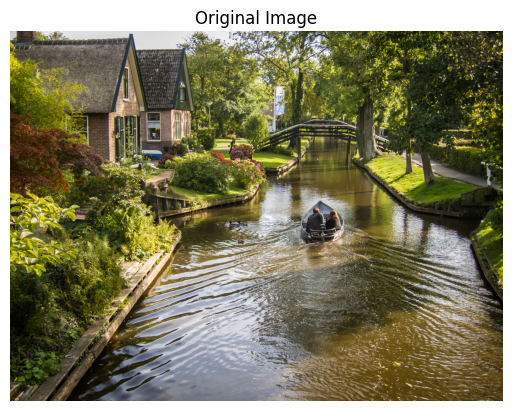

In [75]:
# Get the filename of the uploaded image
image_path = list(uploaded.keys())[0]

# Read the image (OpenCV reads in BGR format)
img_color = cv2.imread(image_path)

# Convert image from BGR to RGB for Matplotlib display
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Convert original color image to grayscale
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Display the original color image
plt.imshow(img_color_rgb) # Show RGB image
plt.title("Original Image") # Set plot title
plt.axis("off") # Turn off axes
plt.show() # Display plot

### Contrast Enhancement with CLAHE

The Contrast Limited Adaptive Histogram Equalization (CLAHE) technique is employed here to significantly improve the local contrast of the image. Unlike global histogram equalization, which applies the same transformation to the entire image, CLAHE operates on small, distinct regions (tiles) of the image. This method is particularly effective at enhancing contrast in images where there are large variations in brightness, preventing the over-amplification of noise that can occur with global methods.

-   **`cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))`**: This function initializes the CLAHE algorithm.
    -   **`clipLimit=2.0`**: This parameter sets the contrast limiting threshold. It's crucial for preventing noise amplification in homogeneous areas. A higher `clipLimit` value will result in more contrast enhancement but can also lead to more visible noise. A value of 2.0 is a common starting point, balancing enhancement with noise suppression.
    -   **`tileGridSize=(8,8)`**: This defines the number of rows and columns that the image is divided into for equalization. For an `(8,8)` grid, the image is divided into 64 tiles. The histogram for each tile is equalized independently, and then the results are combined using bilinear interpolation to remove artificial boundaries. Smaller `tileGridSize` values mean more localized adjustments, which can be beneficial for small details but might introduce artifacts if too small.

CLAHE is applied to both the grayscale version of the image and the L-channel (Lightness) of the LAB color space representation. Applying CLAHE to the L-channel in LAB space is a standard practice for color images because it enhances perceived brightness and contrast without altering the color (A and B channels), thus preserving the natural color appearance.

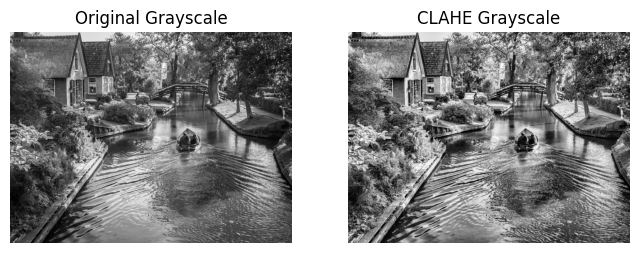

In [76]:
# Create a CLAHE object for contrast enhancement
clahe = cv2.createCLAHE(
    clipLimit=2.0, # Contrast limiting threshold
    tileGridSize=(8,8) # Grid size for equalization
)

# Apply CLAHE to the grayscale image
gray_clahe = clahe.apply(img_gray)

# Display original and CLAHE-enhanced grayscale images
plt.figure(figsize=(8,5))

plt.subplot(1,2,1) # First subplot: original grayscale
plt.imshow(img_gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,2,2) # Second subplot: CLAHE grayscale
plt.imshow(gray_clahe, cmap='gray')
plt.title("CLAHE Grayscale")
plt.axis("off")

plt.show() # Display figure

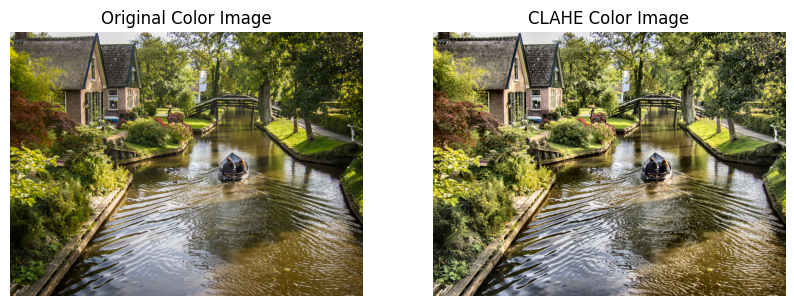

In [77]:
# Convert original BGR image to LAB color space
lab = cv2.cvtColor(img_color, cv2.COLOR_BGR2LAB)

# Split LAB channels (L=lightness, A=green-red, B=blue-yellow)
l, a, b = cv2.split(lab)

# Apply CLAHE to the L-channel (lightness) for contrast enhancement
l_clahe = clahe.apply(l)

# Merge enhanced L-channel with original A and B channels
lab_clahe = cv2.merge((l_clahe, a, b))

# Convert LAB image back to BGR color space
color_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

# Convert BGR to RGB for Matplotlib display
color_clahe_rgb = cv2.cvtColor(color_clahe, cv2.COLOR_BGR2RGB)

# Display original and CLAHE-enhanced color images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1) # First subplot: original RGB color
plt.imshow(img_color_rgb)
plt.title("Original Color Image")
plt.axis("off")

plt.subplot(1,2,2) # Second subplot: CLAHE RGB color
plt.imshow(color_clahe_rgb)
plt.title("CLAHE Color Image")
plt.axis("off")

plt.show() # Display figure

In [78]:
cv2.imwrite("clahe_grayscale.jpg", gray_clahe) # Save CLAHE grayscale image
cv2.imwrite("clahe_color.jpg", color_clahe) # Save CLAHE color image (BGR format)

print("Images saved successfully!") # Confirmation message

Images saved successfully!


### Blurring Operations

Image blurring is a fundamental image processing technique used to reduce noise, smooth out details, and prepare images for further processing. Different blurring filters operate based on distinct mathematical principles and are suited for different types of noise or desired effects.

-   **Average Blur (`cv2.blur`)**: This is the simplest blurring technique. Each pixel's new value is the average of all pixel values within a defined rectangular neighborhood (kernel) around it.
    -   **`cv2.blur(img_color, (51,51))`**: The `(51,51)` kernel size means a 51x51 pixel area is averaged for each pixel. A larger kernel size results in a more pronounced blurring effect, as more surrounding pixels contribute to the average, leading to greater smoothing. This type of blur is effective for simple noise reduction and smoothing.

-   **Gaussian Blur (`cv2.GaussianBlur`)**: Gaussian blur uses a Gaussian function to calculate the transformation applied to each pixel. Pixels closer to the center of the kernel contribute more weight to the output pixel's value than those further away. This produces a softer, more natural-looking blur compared to average blur.
    -   **`cv2.GaussianBlur(img_color, (51,51), 0)`**:
        -   The `(51,51)` kernel size defines the width and height of the Gaussian kernel, which **must be odd and positive**. A larger kernel provides a stronger blur.
        -   The `0` for `sigmaX` (standard deviation in X direction) and `sigmaY` (if not specified, it's taken as `sigmaX`) instructs OpenCV to calculate these values automatically based on the kernel size. This ensures an optimal Gaussian distribution for the given kernel dimensions. Gaussian blur is particularly good at removing Gaussian noise.

-   **Median Blur (`cv2.medianBlur`)**: Unlike average or Gaussian blur, median blur is a non-linear filter that replaces each pixel's value with the median value of its neighboring pixels within the kernel.
    -   **`cv2.medianBlur(img_color, 51)`**: The `51` is the kernel size, which **must be a single odd integer**. This filter is highly effective at removing "salt-and-pepper" noise (random bright or dark pixels) while preserving edges better than linear filters. Its non-linear nature makes it computationally more intensive but very robust against impulse noise.

In all cases, increasing the kernel size significantly amplifies the blurring effect, leading to a smoother image with less fine detail.

In [79]:
# Apply Average Blur to the color image
# (51,51) is the kernel size; larger kernel means more blur
average_blur = cv2.blur(img_color, (51,51))

# Apply Gaussian Blur to the color image
# (51,51) is kernel size (must be odd); 0 calculates sigma values
gaussian_blur = cv2.GaussianBlur(img_color, (51,51), 0)

# Apply Median Blur to the color image
# 51 is kernel size (must be odd); effective for noise reduction
median_blur = cv2.medianBlur(img_color, 51)

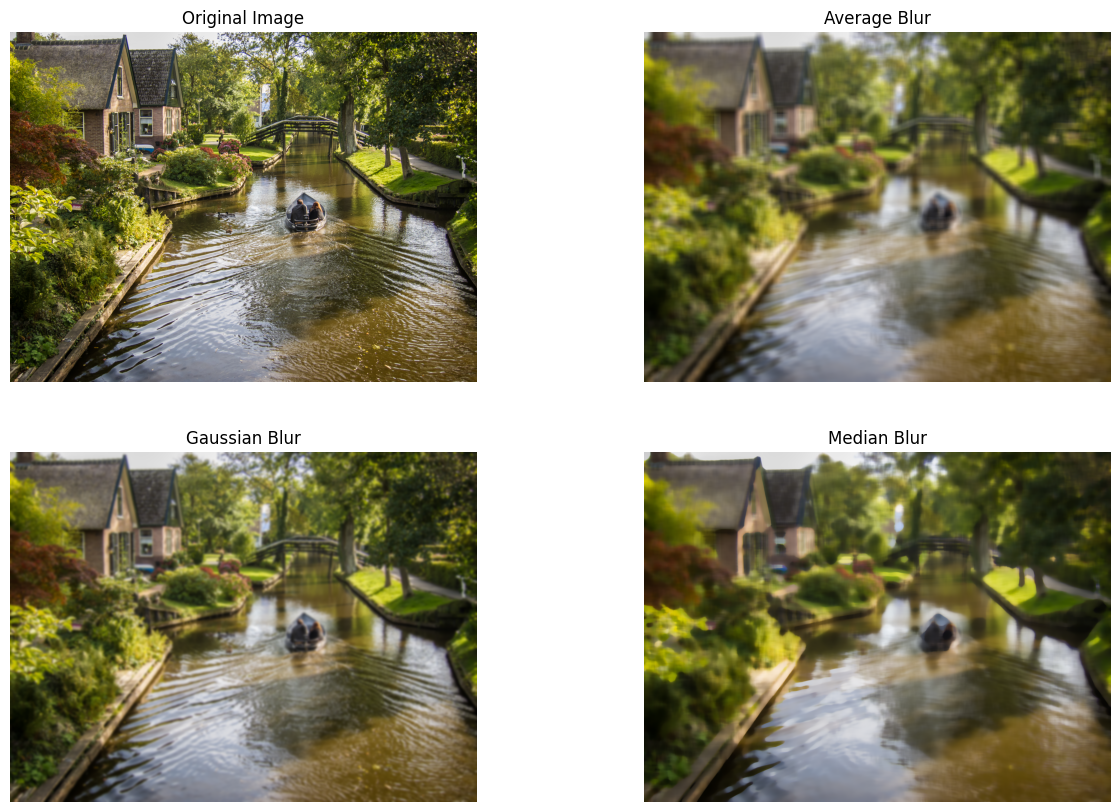

In [80]:
plt.figure(figsize=(15,10)) # Create figure for multiple plots

# Subplot 1: Original RGB image
plt.subplot(2,2,1)
plt.imshow(img_color_rgb)
plt.title("Original Image")
plt.axis("off")

# Subplot 2: Average Blurred image (convert BGR to RGB for display)
plt.subplot(2,2,2)
plt.imshow(cv2.cvtColor(average_blur, cv2.COLOR_BGR2RGB))
plt.title("Average Blur")
plt.axis("off")

# Subplot 3: Gaussian Blurred image (convert BGR to RGB for display)
plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

# Subplot 4: Median Blurred image (convert BGR to RGB for display)
plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB))
plt.title("Median Blur")
plt.axis("off")

plt.show() # Display all subplots

### Sharpening Operation

Image sharpening is an enhancement technique that accentuates edges and fine details within an image, making it appear clearer and more defined. This is typically achieved through a process called **convolution**, where a small matrix called a **kernel** (or convolution matrix) is passed over each pixel of the image.

-   **Convolution Process**: For each pixel in the image, the kernel is centered over it, and a new pixel value is calculated by multiplying each element of the kernel with the corresponding pixel value in the image under the kernel, and then summing up these products.

-   **Sharpening Kernel**: The specific `sharpen_kernel` used here is:
    ```
    [[0, -1, 0],
     [-1,  5, -1],
     [0, -1, 0]]
    ```
    -   The `5` in the center represents a strong positive weight for the central pixel.
    -   The `-1` values for the immediate neighbors (top, bottom, left, right) indicate a negative contribution from these surrounding pixels.
    -   The `0` values for the corner pixels mean they don't contribute to the new pixel value.
    This kernel works by increasing the value of the central pixel relative to its neighbors. If a pixel is significantly different from its neighbors (i.e., it's an edge), this kernel will exaggerate that difference, thereby enhancing the edge. The sum of the kernel elements is 1 (0-1+0-1+5-1+0-1+0 = 1), which ensures that the overall brightness of the image is preserved.

-   **`cv2.filter2D(img_color, -1, sharpen_kernel)`**: This function applies the defined `sharpen_kernel` to the `img_color`.
    -   `img_color`: The source image to be sharpened.
    -   `-1`: This parameter indicates that the output image will have the same depth (data type) as the input image. If a different depth is desired, it can be specified (e.g., `cv2.CV_8U` for 8-bit unsigned integer).
    -   `sharpen_kernel`: The 2D array representing the convolution kernel.

The result is an image where edges and details are more prominent, often giving the impression of increased clarity.

In [81]:
# Define a sharpening kernel (convolution matrix)
# Emphasizes central pixel, reduces neighbors for edge enhancement
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Apply the sharpening filter to the color image
# -1 indicates output depth same as input
sharpened = cv2.filter2D(img_color, -1, sharpen_kernel)

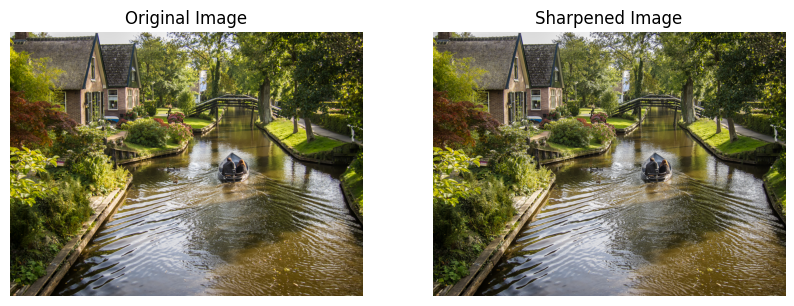

In [82]:
plt.figure(figsize=(10,5)) # Create figure for two plots

# Subplot 1: Original RGB image
plt.subplot(1,2,1)
plt.imshow(img_color_rgb)
plt.title("Original Image")
plt.axis("off")

# Subplot 2: Sharpened image (convert BGR to RGB for display)
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title("Sharpened Image")
plt.axis("off")

plt.show() # Display both subplots

### Detailed Color Space Comparisons

Understanding how image processing operations affect different color channels is crucial for effective image manipulation. Images are typically represented in various **color spaces**, each designed to separate color information in a particular way. This section compares the original and processed images across three common color spaces: RGB, HSV, and LAB.

-   **RGB (Red, Green, Blue)**:
    -   **Representation**: This is the most common color space, where colors are represented by the intensity of red, green, and blue light components. Each pixel has three values corresponding to its red, green, and blue channels.
    -   **Interpretation**: RGB is ideal for display and directly relates to how screens emit light. However, modifying individual RGB channels can drastically alter perceived color, brightness, and saturation simultaneously, making targeted adjustments challenging.

-   **HSV (Hue, Saturation, Value)**:
    -   **Representation**: HSV decomposes color into three components that align more closely with human perception:
        -   **Hue (H)**: Represents the pure color (e.g., red, yellow, green). It is expressed as an angle from 0-179 or 0-360 degrees.
        -   **Saturation (S)**: Describes the purity or intensity of the color. A fully saturated color is pure, while a saturation of zero results in a shade of gray. It ranges from 0-255.
        -   **Value (V)** (also known as Brightness): Represents the lightness or darkness of the color. A value of 0 is pure black. It ranges from 0-255.
    -   **Interpretation**: HSV is very intuitive for color-based adjustments. For example, you can change the color tone (Hue) without affecting its brightness or vibrancy, or desaturate a color without changing its basic hue. When displayed, HSV images are typically converted back to RGB for visual consistency, as native HSV rendering might look unusual.

-   **LAB (L*, a*, b*)**:
    -   **Representation**: The LAB color space is designed to approximate human vision, where 'L' stands for lightness, and 'a' and 'b' are color-opponent dimensions.
        -   **L* (Lightness)**: Represents the perceived lightness of the color, ranging from 0 (black) to 100 (white). In OpenCV, this is often scaled to 0-255.
        -   **a***: Represents the green-red opponent colors, ranging from green (negative values) to red (positive values).
        -   **b***: Represents the blue-yellow opponent colors, ranging from blue (negative values) to yellow (positive values).
    -   **Interpretation**: LAB is device-independent and is particularly useful for color correction and image enhancement because the L-channel (lightness) is separated from the color information (a and b channels). This allows for independent manipulation of brightness without affecting color, or vice-versa. For example, CLAHE was applied to the L-channel to enhance contrast without distorting the image's original colors. Similar to HSV, LAB images are converted to RGB for standard display.

By visualizing images in these different color spaces, we can gain deeper insights into how processing operations like contrast enhancement, blurring, and sharpening specifically impact the lightness, color tones, and saturation of the image, offering a more analytical perspective beyond just the RGB output.

## Comparison of HSV and LAB Color Spaces
This section compares original and processed images in HSV and LAB color spaces. This helps observe how processing affects color and lightness components.

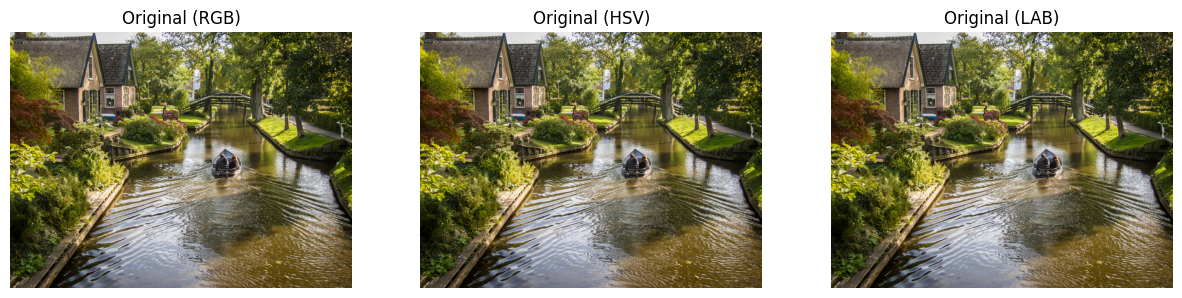

In [84]:
# --- Original Image Color Space Comparisons ---

# Convert original BGR image to HSV color space
original_hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)

# Convert original BGR image to LAB color space
original_lab = cv2.cvtColor(img_color, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 5)) # Figure for three subplots

plt.subplot(1, 3, 1) # Subplot 1: Original RGB
plt.imshow(img_color_rgb)
plt.title("Original (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2) # Subplot 2: Original HSV (converted to RGB for display)
plt.imshow(cv2.cvtColor(original_hsv, cv2.COLOR_HSV2RGB))
plt.title("Original (HSV)")
plt.axis("off")

plt.subplot(1, 3, 3) # Subplot 3: Original LAB (converted to RGB for display)
plt.imshow(cv2.cvtColor(original_lab, cv2.COLOR_LAB2RGB))
plt.title("Original (LAB)")
plt.axis("off")

plt.show() # Display figure

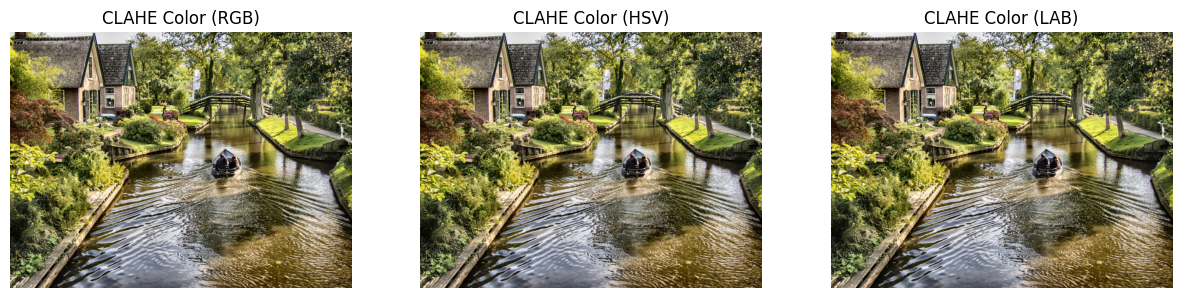

In [85]:
# --- CLAHE Color Image Color Space Comparisons ---

# `color_clahe` is the CLAHE-enhanced color image (BGR format)

# Convert CLAHE color image (BGR) to HSV color space
clahe_color_hsv = cv2.cvtColor(color_clahe, cv2.COLOR_BGR2HSV)

# Convert CLAHE color image (BGR) to LAB color space
clahe_color_lab = cv2.cvtColor(color_clahe, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 5)) # Figure for three subplots

plt.subplot(1, 3, 1) # Subplot 1: CLAHE Color RGB
plt.imshow(color_clahe_rgb)
plt.title("CLAHE Color (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2) # Subplot 2: CLAHE Color HSV (converted to RGB for display)
plt.imshow(cv2.cvtColor(clahe_color_hsv, cv2.COLOR_HSV2RGB))
plt.title("CLAHE Color (HSV)")
plt.axis("off")

plt.subplot(1, 3, 3) # Subplot 3: CLAHE Color LAB (converted to RGB for display)
plt.imshow(cv2.cvtColor(clahe_color_lab, cv2.COLOR_LAB2RGB))
plt.title("CLAHE Color (LAB)")
plt.axis("off")

plt.show() # Display figure

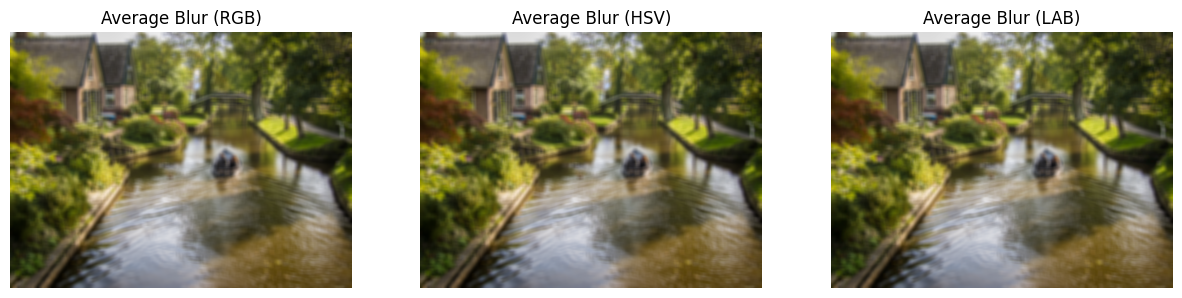

In [86]:
# --- Average Blur Image Color Space Comparisons ---

# `average_blur` is the average blurred image (BGR format)

# Convert average blurred image (BGR) to HSV color space
average_blur_hsv = cv2.cvtColor(average_blur, cv2.COLOR_BGR2HSV)

# Convert average blurred image (BGR) to LAB color space
average_blur_lab = cv2.cvtColor(average_blur, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 5)) # Figure for three subplots

plt.subplot(1, 3, 1) # Subplot 1: Average Blur RGB
plt.imshow(cv2.cvtColor(average_blur, cv2.COLOR_BGR2RGB))
plt.title("Average Blur (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2) # Subplot 2: Average Blur HSV (converted to RGB for display)
plt.imshow(cv2.cvtColor(average_blur_hsv, cv2.COLOR_HSV2RGB))
plt.title("Average Blur (HSV)")
plt.axis("off")

plt.subplot(1, 3, 3) # Subplot 3: Average Blur LAB (converted to RGB for display)
plt.imshow(cv2.cvtColor(average_blur_lab, cv2.COLOR_LAB2RGB))
plt.title("Average Blur (LAB)")
plt.axis("off")

plt.show() # Display figure

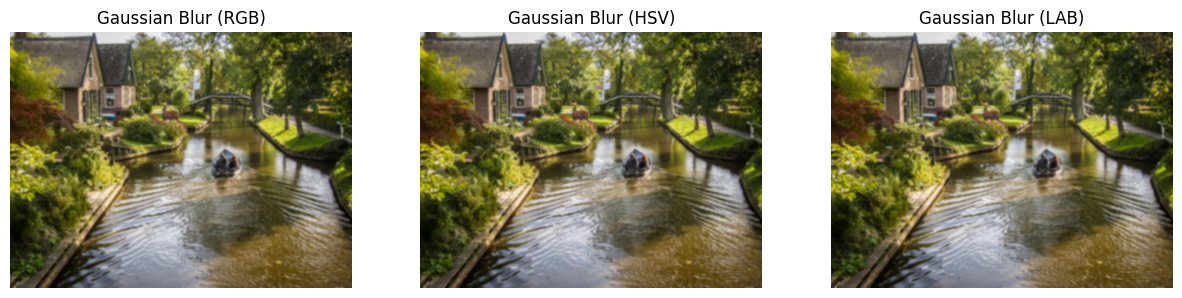

In [87]:
# --- Gaussian Blur Image Color Space Comparisons ---

# `gaussian_blur` is the Gaussian blurred image (BGR format)

# Convert Gaussian blurred image (BGR) to HSV color space
gaussian_blur_hsv = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2HSV)

# Convert Gaussian blurred image (BGR) to LAB color space
gaussian_blur_lab = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 5)) # Figure for three subplots

plt.subplot(1, 3, 1) # Subplot 1: Gaussian Blur RGB
plt.imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2) # Subplot 2: Gaussian Blur HSV (converted to RGB for display)
plt.imshow(cv2.cvtColor(gaussian_blur_hsv, cv2.COLOR_HSV2RGB))
plt.title("Gaussian Blur (HSV)")
plt.axis("off")

plt.subplot(1, 3, 3) # Subplot 3: Gaussian Blur LAB (converted to RGB for display)
plt.imshow(cv2.cvtColor(gaussian_blur_lab, cv2.COLOR_LAB2RGB))
plt.title("Gaussian Blur (LAB)")
plt.axis("off")

plt.show() # Display figure

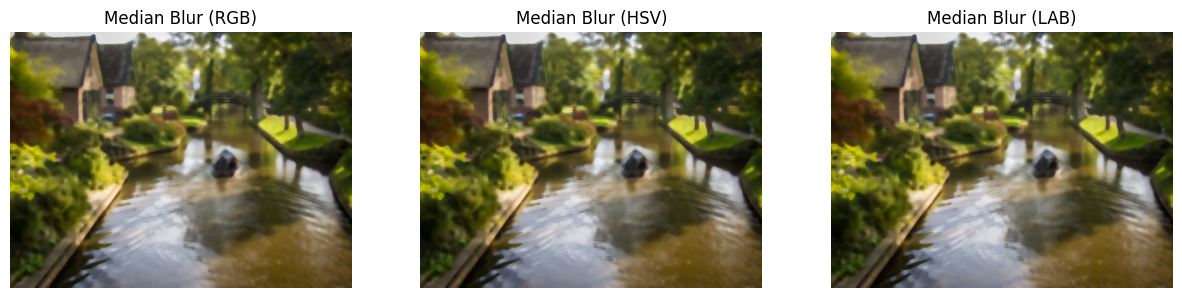

In [88]:
# --- Median Blur Image Color Space Comparisons ---

# `median_blur` is the median blurred image (BGR format)

# Convert median blurred image (BGR) to HSV color space
median_blur_hsv = cv2.cvtColor(median_blur, cv2.COLOR_BGR2HSV)

# Convert median blurred image (BGR) to LAB color space
median_blur_lab = cv2.cvtColor(median_blur, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 5)) # Figure for three subplots

plt.subplot(1, 3, 1) # Subplot 1: Median Blur RGB
plt.imshow(cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB))
plt.title("Median Blur (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2) # Subplot 2: Median Blur HSV (converted to RGB for display)
plt.imshow(cv2.cvtColor(median_blur_hsv, cv2.COLOR_HSV2RGB))
plt.title("Median Blur (HSV)")
plt.axis("off")

plt.subplot(1, 3, 3) # Subplot 3: Median Blur LAB (converted to RGB for display)
plt.imshow(cv2.cvtColor(median_blur_lab, cv2.COLOR_LAB2RGB))
plt.title("Median Blur (LAB)")
plt.axis("off")

plt.show() # Display figure

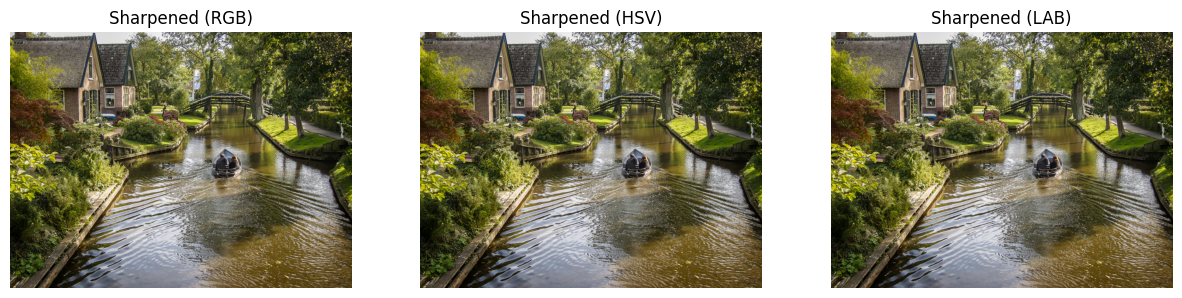

In [89]:
# --- Sharpened Image Color Space Comparisons ---

# `sharpened` is the sharpened image (BGR format)

# Convert sharpened image (BGR) to HSV color space
sharpened_hsv = cv2.cvtColor(sharpened, cv2.COLOR_BGR2HSV)

# Convert sharpened image (BGR) to LAB color space
sharpened_lab = cv2.cvtColor(sharpened, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 5)) # Figure for three subplots

plt.subplot(1, 3, 1) # Subplot 1: Sharpened RGB
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title("Sharpened (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2) # Subplot 2: Sharpened HSV (converted to RGB for display)
plt.imshow(cv2.cvtColor(sharpened_hsv, cv2.COLOR_HSV2RGB))
plt.title("Sharpened (HSV)")
plt.axis("off")

plt.subplot(1, 3, 3) # Subplot 3: Sharpened LAB (converted to RGB for display)
plt.imshow(cv2.cvtColor(sharpened_lab, cv2.COLOR_LAB2RGB))
plt.title("Sharpened (LAB)")
plt.axis("off")

plt.show() # Display figure

In [83]:
cv2.imwrite("average_blur.jpg", average_blur) # Save average blurred image
cv2.imwrite("gaussian_blur.jpg", gaussian_blur) # Save Gaussian blurred image
cv2.imwrite("median_blur.jpg", median_blur) # Save median blurred image
cv2.imwrite("sharpened_image.jpg", sharpened) # Save sharpened image

print("Blurred and sharpened images saved successfully!") # Confirmation message

Blurred and sharpened images saved successfully!


## Resources

This section serves as a comprehensive reference point for all external materials, documentation, datasets, and tools utilized or mentioned within this notebook. Its purpose is to provide clear pathways for reproducibility, further research, and deeper understanding of the concepts and methodologies applied. Each entry typically includes:

*   **Links to Original Data Sources**: Where the raw data was obtained from.
*   **Documentation Links**: Pointers to official documentation for libraries (e.g., OpenCV, NumPy, Matplotlib) or specific algorithms used.
*   **Research Papers/Articles**: Academic or technical papers that inform the theoretical background or specific techniques implemented.
*   **Relevant Tutorials/Examples**: External guides or code examples that were consulted during the development of the notebook.
*   **Tool Information**: Details about any specialized software or platforms that are essential for replicating the environment or analysis.